# FoodHub Analytics_Restaurant Demand & Delivery Insights

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order\_id: Unique ID of the order
* customer\_id: ID of the customer who ordered the food
* restaurant\_name: Name of the restaurant
* cuisine\_type: Cuisine ordered by the customer
* cost\_of\_the\_order: Cost of the order
* day\_of\_the\_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food\_preparation\_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery\_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [5]:
# Installing the libraries with the specified version.
!pip install numpy==2.0.2 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2 -q --user

In [6]:
# Import libraries for data manipulation
import numpy as np
import pandas as pd

# Import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

## Understanding the structure of the dataset

In [7]:
# Mount Google Drive to access files stored in Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
# Load the dataset from Drive into Colab
foodhub_df = pd.read_csv('/content/drive/MyDrive/Projects/FoodHub Analytics_Restaurant Demand & Delivery Insights/FoodHub_Order.csv')

In [9]:
# View the first 5 rows
foodhub_df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


### Total Number of Rows and Columns

In [10]:
# Check the total number of rows and columns present in the dataset
foodhub_df.shape

(1898, 9)

**Observations:**

There are total **1898** rows or records and **9** columns in the FoodHub\_Order dataset.

### Data Types of Variables in the Dataset

In [11]:
# Check the datatypes of the different columns in the dataset
foodhub_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


**Observations:**

* The datatype of the column **cost\_of\_the\_order** is 'float64.'
* The datatype of the columns **order\_id, customer\_id, food\_preparation\_time, and delivery\_time** is 'int64.'
* The datatype of the columns **restaurant\_name, cuisine\_type, day\_of\_the\_week, and rating** is 'object.'

In conclusion, the datatype of 1 attribute is 'float64', the datatype of 4 attributes is 'int64' and the datatype of the remaining 4 attributes is 'object.'

### Identification and Treatment of Missing Values in the Dataset

In [12]:
# Check for the missing values in the dataset
foodhub_df.isnull().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


**Observations:**

There are no missing values in any of the columns of the FoodHub dataset.

### Statistical Summary of Dataset and Minimum, Average, & Maximum values of food\_preparation\_time

In [13]:
# Check the statistical summary of the Numerical data
foodhub_df.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
order_id,1898.0,1.477496e+06,548.049724,1476547.00,1477021.25,1477495.50,1.477970e+06,1478444.00
customer_id,1898.0,1.711685e+05,113698.139743,1311.00,77787.75,128600.00,2.705250e+05,405334.00
cost_of_the_order,1898.0,1.649885e+01,7.483812,4.47,12.08,14.14,2.229750e+01,35.41
food_preparation_time,1898.0,2.737197e+01,4.632481,20.00,23.00,27.00,3.100000e+01,35.00
delivery_time,1898.0,2.416175e+01,4.972637,15.00,20.00,25.00,2.800000e+01,33.00


In [14]:
# Check the statistical summary of the Categorical data
foodhub_df.describe(include='object').T

,count,unique,top,freq
restaurant_name,1898,178,Shake Shack,219
cuisine_type,1898,14,American,584
day_of_the_week,1898,2,Weekend,1351
rating,1898,4,Not given,736


**Observations:**

* The minimum amount of time it takes for the food to be prepared at the restaurant once an order is placed is **20 minutes**.
* The maximum amount of time it takes for the food to be prepared at the restaurant once an order is placed is **35 minutes**.
* The average amount of time it takes for the food to be prepared at the restaurant once an order is placed is **27.37 minutes**.

### Total number of Unrated Orders in the Dataset

In [15]:
# Check the count of each unique value in the rating column
foodhub_df['rating'].value_counts()

,count
rating,
Not given,736
5,588
4,386
3,188


**Observations:**

The total number of orders that are not rated are **736**.

## Exploratory Data Analysis (EDA)

### Univariate Analysis

#### Univariate analysis of all variables and their Distributions (histograms, boxplots, countplots)

##### Different unique values in each categorical variable and their count

In [16]:
# Create a variable with only categorical columns
categoric_columns = foodhub_df.select_dtypes(include = 'object').columns

# Check the count of each unique value in the catergorical column using for loop
for col in categoric_columns:
  print(foodhub_df[col].value_counts())
  print(50 * '-')

restaurant_name
Shake Shack                  219
The Meatball Shop            132
Blue Ribbon Sushi            119
Blue Ribbon Fried Chicken     96
Parm                          68
                            ... 
Rye House                      1
Hiroko's Place                 1
Frank Restaurant               1
Sarabeth's West                1
'wichcraft                     1
Name: count, Length: 178, dtype: int64
--------------------------------------------------
cuisine_type
American          584
Japanese          470
Italian           298
Chinese           215
Mexican            77
Indian             73
Middle Eastern     49
Mediterranean      46
Thai               19
French             18
Southern           17
Korean             13
Spanish            12
Vietnamese          7
Name: count, dtype: int64
--------------------------------------------------
day_of_the_week
Weekend    1351
Weekday     547
Name: count, dtype: int64
--------------------------------------------------
rating
N

##### Histogram of cost\_of\_the\_order, food\_preparation\_time, delivery\_time

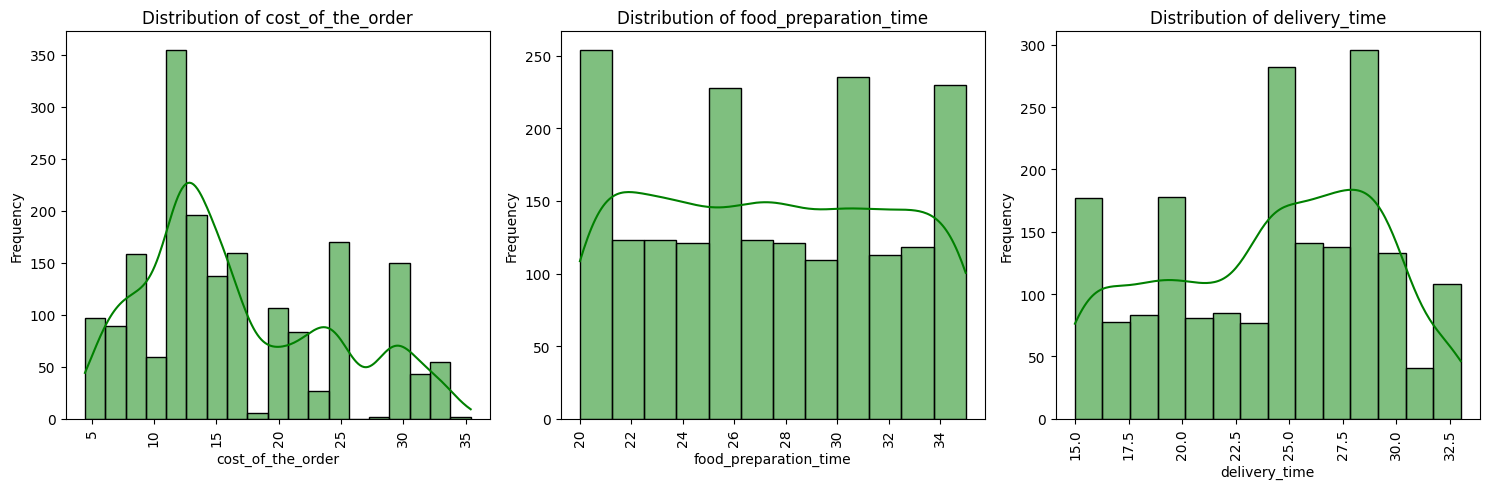

In [17]:
# Create a variable with only numerical columns
numeric_columns = foodhub_df.select_dtypes(include = 'number').columns

# Drop order_id, customer_id columns from numeric_columns variable as they are not necessary for visualization
numeric_columns = numeric_columns.drop(['order_id', 'customer_id'])

# Create a histogram of numeric columns using for loop
plt.figure(figsize = (15, 5))

for i, col in enumerate(numeric_columns):
  plt.subplot(1, 3, i+1) # Create a subplot in a grid of 1 row and 3 columns
  sns.histplot(data = foodhub_df, x = col, kde = True, color = 'Green')
  plt.title(f'Distribution of {col}')
  plt.xticks(rotation = 90)
  plt.xlabel(col)
  plt.ylabel('Frequency')
  plt.tight_layout()

plt.show()

**Observations:**

1. Distribution of cost of the order

* Most orders cost between 10 and 20 dollars.
* There are fewer very low-cost orders (below 7 dollars).
* There are also fewer high-cost orders (above 30 dollars).
* The majority of customers seem to place medium-priced orders.

2. Distribution of food preparation time

* Most food preparation times are between 20 and 35 minutes.
* The preparation time looks fairly evenly spread within this range.
* There are no extreme very low or very high preparation times.
* On average, food preparation takes around 25 to 30 minutes.

3. Distribution of delivery time

* Most deliveries take between 20 and 30 minutes.
* Very few deliveries are extremely fast (below 16 minutes) or very slow (above 32 minutes).
* The average delivery time appears to be around 25 to 28 minutes.
* Delivery times are slightly concentrated around the middle range.-

##### Box Plot of cost\_of\_the\_order, food\_preparation\_time, delivery\_time

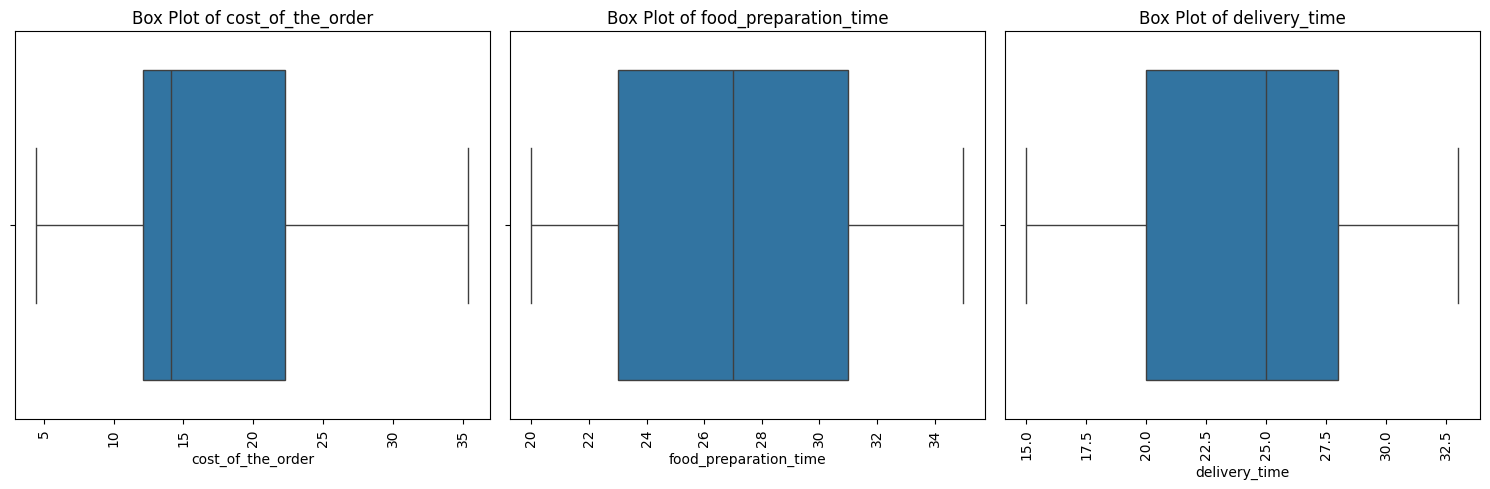

In [18]:
# Create a variable with only numerical columns
numeric_columns = foodhub_df.select_dtypes(include = 'number').columns

# Drop order_id, customer_id columns from numeric_columns variable as they are not necessary for visualization
numeric_columns = numeric_columns.drop(['order_id', 'customer_id'])

# Create a box plot of numeric columns using for loop
plt.figure(figsize = (15, 5))

for i, col in enumerate(numeric_columns):
  plt.subplot(1, 3, i+1) # Create a subplot in a grid of 1 row and 3 columns
  sns.boxplot(data = foodhub_df, x = col)
  plt.title(f'Box Plot of {col}')
  plt.xticks(rotation = 90)
  plt.xlabel(col)
  plt.tight_layout()

plt.show()

**Observations:**

1. Box plot of cost of the order

* The middle 50% of order costs are roughly between 12 and 22 dollars.
* The median (middle value) is around 15 dollars.
* The minimum cost is around 5 dollars, and the maximum is around 35 dollars.
* There are no strong outliers, but there is a wider spread on the higher cost side.

2. Box plot of food preparation time

* The middle 50% of preparation times are between 23 and 31 minutes.
* The median preparation time is around 27 minutes.
* The shortest preparation time is about 20 minutes, and the longest is about 35 minutes.
  The spread is fairly balanced, showing consistent preparation times.

3. Box plot of delivery time

* The middle 50% of delivery times are between 20 and 28 minutes.
* The median delivery time is around 25 minutes.
* Delivery times range from about 15 minutes to 33 minutes.
* The data looks fairly evenly distributed without extreme outliers.

##### Count Plot of cuisine\_type, day\_of\_the\_week, rating

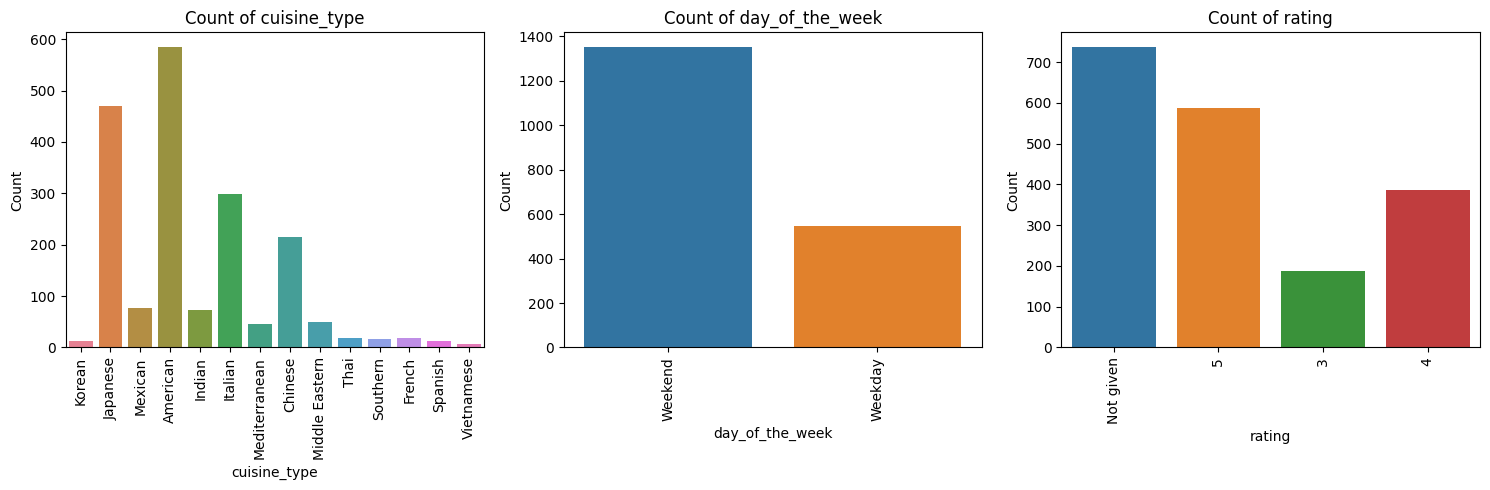

In [19]:
# Create a variable with only categorical columns
categoric_columns = foodhub_df.select_dtypes(include = 'object').columns

# Drop restaurant_name column from categoric_columns variable as they are not necessary for visualization
categoric_columns = categoric_columns.drop(['restaurant_name'])

# Create a count plot of categoric columns using for loop
plt.figure(figsize = (15, 5))

for i, col in enumerate(categoric_columns):
  plt.subplot(1, 3, i+1) # Create a subplot in a grid of 1 row and 3 columns
  sns.countplot(data = foodhub_df, x = col, hue = col)
  plt.title(f'Count of {col}')
  plt.xticks(rotation = 90)
  plt.xlabel(col)
  plt.ylabel('Count')
  plt.tight_layout()

plt.show()

**Observations:**

1. Count of cuisine type

* American cuisine has the highest number of orders.
* Japanese cuisine is the second most popular.
* Italian and Chinese cuisines also have a good number of orders.
* Some cuisines like Korean, Spanish, Vietnamese, French, and Thai have very few orders.
* This shows that customer demand is mainly concentrated in a few popular cuisines.

2. Count of day of the week

* There are many more orders on weekends compared to weekdays.
* Weekend orders are more than double the weekday orders.
* This suggests that customers prefer ordering food more during weekends.

3. Count of rating

* A large number of orders have no rating given.
* Among the ratings provided, 5-star ratings are the highest.
* 4-star ratings are also common.
* 3-star ratings are the least among the given ratings.
* Overall, most of the ratings are positive (4 and 5), which suggests good customer satisfaction.

#### Top 5 restaurants by number of orders received

In [20]:
# Group the data by restaurant_name
# Check the count of orders of each restaurant
# Sort the values in the descending order by setting ascending to False
foodhub_df.groupby('restaurant_name')['order_id'].count().sort_values(ascending = False).head(5)

,order_id
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68


**Observations:**

* **The top five restaurants are Shake Shack, The Meatball Shop, Blue Ribbon Sushi, Blue Ribbon Fried Chicken and Parm**
* Shake shack has the highest number of orders (219), clearly leading among all restaurants.
* The meatball shop is the second most popular with 132 orders, but it is far behind shake shack.
* Blue ribbon sushi and blue ribbon fried chicken also receive a good number of orders.
* Parm has the lowest number of orders among the top five.
* There is a noticeable gap between the first restaurant and the rest, showing that shake shack is much more popular compared to others.
* Overall, a small group of restaurants is generating a large share of total orders.

#### Most popular cuisine on weekends

In [21]:
# Filter the dataset where the day_of_the_week is weekend
# Check count of each unique value in the cuisine_type column
foodhub_df[foodhub_df['day_of_the_week'] == 'Weekend']['cuisine_type'].value_counts()

,count
cuisine_type,
American,415
Japanese,335
Italian,207
Chinese,163
Mexican,53
Indian,49
Middle Eastern,32
Mediterranean,32
Thai,15


**Observations:**

* **American cuisine is the most popular on weekends with 415 orders.**
* Japanese cuisine is the second most popular with 335 orders.
* Italian and Chinese cuisines also have strong demand on weekends.
* Cuisines like Vietnamese, Korean, Southern, Spanish, and French have very low weekend orders.
* Weekend demand is clearly concentrated in a few major cuisines, especially American and Japanese.
* This suggests customers prefer familiar and popular cuisines when ordering on weekends.

#### Percentage of orders costing more than 20 dollars

In [22]:
# Filter the dataset with the cost_of_the_order greater than 20 dollars and get the count of it
# The divide it by total number of rows and multiply the resulted value with 100 to get the percentage
(foodhub_df[foodhub_df['cost_of_the_order'] > 20]['order_id'].count() / foodhub_df.shape[0]) * 100

np.float64(29.24130663856691)

**Observations:**

* **Approximately 29.24% of the orders cost more than 20 dollars.**
* This means that nearly 3 out of every 10 orders are high-value orders (above 20 dollars).
* The majority of orders (around 70%) cost 20 dollars or less, showing that most customers prefer moderately priced meals.

#### Mean order delivery time

In [23]:
# Calculate the average delivery time
foodhub_df['delivery_time'].mean()

np.float64(24.161749209694417)

**Observations:**

* The mean order delivery time is approximately 24.16 minutes.

#### Top 5 most frequent customers and their order counts for 20% discount vouchers

In [24]:
# Group the data by customer_id and check the count of order_id of each customer
# Sort the values in the descending order by setting ascending to False
foodhub_df.groupby('customer_id')['order_id'].count().sort_values(ascending = False).head(5)

,order_id
customer_id,
52832,13
47440,10
83287,9
250494,8
276192,7


**Observations:**

* The top 5 most frequent customers are:
  1. Customer id 52832 – placed 13 orders
  2. Customer id 47440 – placed 10 orders
  3. Customer id 83287 – placed 9 orders
  4. Customer id 250494 – placed 8 orders
  5. Customer id 276192 – placed 7 orders
* Customer 52832 is the most loyal customer with the highest number of orders.
* These customers place orders significantly more frequently than others.
* Offering 20% discount vouchers to these customers is a good strategy to reward loyalty and encourage continued ordering.

### Multivariate Analysis

#### Multivariate analysis of relationships between important variables in the dataset

##### Box Plot of Cuisine\_type Vs Cost\_of\_the\_order & Cuisine\_type Vs food\_preparation\_time

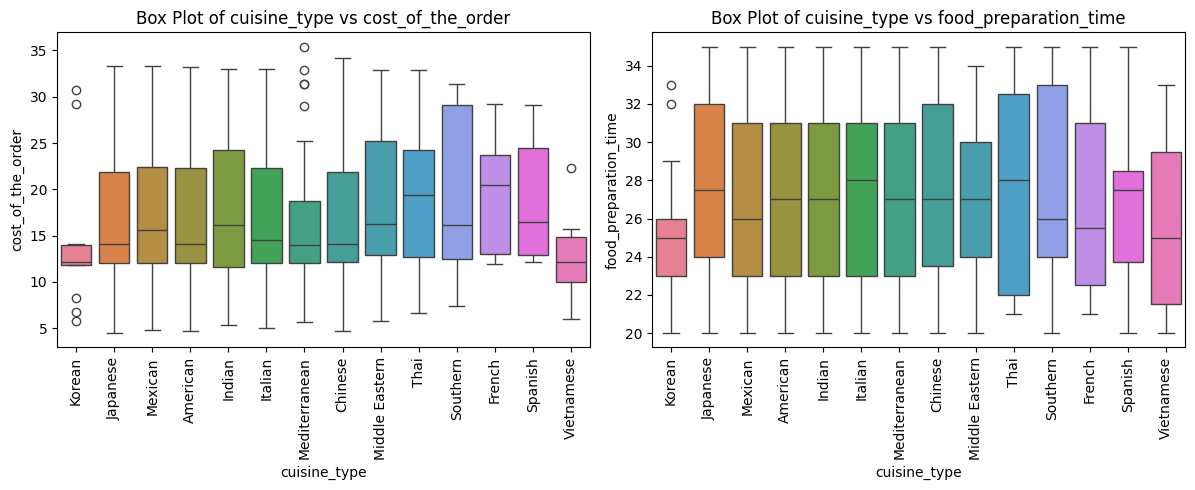

In [25]:
# Create a variable with only numerical columns
numeric_columns = foodhub_df.select_dtypes(include = 'number').columns

# Drop order_id, customer_id, delivery_time columns from numeric_columns variable as they are not necessary for visualization
numeric_columns = numeric_columns.drop(['order_id', 'customer_id', 'delivery_time'])

# Create box plots of each numeric column with hue as cuisine_type using for loop
plt.figure(figsize = (18, 5))

for i, col in enumerate(numeric_columns):
  plt.subplot(1, 3, i+1) # Create a subplot in a grid of 1 row and 3 columns
  sns.boxplot(data = foodhub_df, x = 'cuisine_type', y = col, hue = 'cuisine_type')
  plt.title(f'Box Plot of cuisine_type vs {col}')
  plt.xlabel('cuisine_type')
  plt.ylabel(col)
  plt.xticks(rotation = 90)
  plt.tight_layout()

plt.show()

**Observations:**

1. Cuisine type vs cost of the order

* French, Thai, and Spanish cuisines generally have higher median order costs compared to others.
* American, Mexican, Italian, and Indian cuisines have moderate order costs.
* Vietnamese and Korean cuisines tend to have lower order costs.
* Some cuisines like Mediterranean and Japanese show a wider spread in cost, meaning prices vary more.
* A few cuisines have some higher-cost outliers, showing occasional expensive orders.

2. Cuisine type vs food preparation time

* Most cuisines have preparation times between 23 and 30 minutes.
* Thai, Southern, and Chinese cuisines tend to have slightly higher preparation times.
* Vietnamese and Korean cuisines generally have slightly lower preparation times.
* The preparation time does not vary drastically across cuisines — it is fairly consistent.
* Some cuisines show a wider range of preparation times, meaning some orders take much longer than others.

##### Box Plot of day\_of\_the\_week Vs delivery\_time

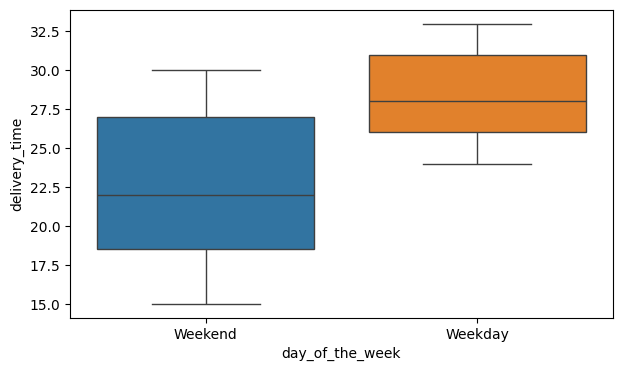

In [26]:
# Create a boxplot to visualize the distribution of delivery_time across different categories of day_of_the_week
plt.figure(figsize = (7, 4))
sns.boxplot(data = foodhub_df, x = 'day_of_the_week', y = 'delivery_time', hue = 'day_of_the_week')
plt.show()

**Observations:**

* The median delivery time on weekdays is higher than on weekends.
* On average, weekday deliveries take around 28 minutes, while weekend deliveries take around 22 minutes.
* Delivery times on weekdays are more consistent and slightly concentrated in the higher range.
* Weekend delivery times show more variation, with some orders delivered quite quickly.
* Overall, deliveries tend to take longer on weekdays compared to weekends.

##### Point Plot of rating Vs cost\_of\_the\_order, rating Vs food\_preparation time & rating Vs delivery\_time

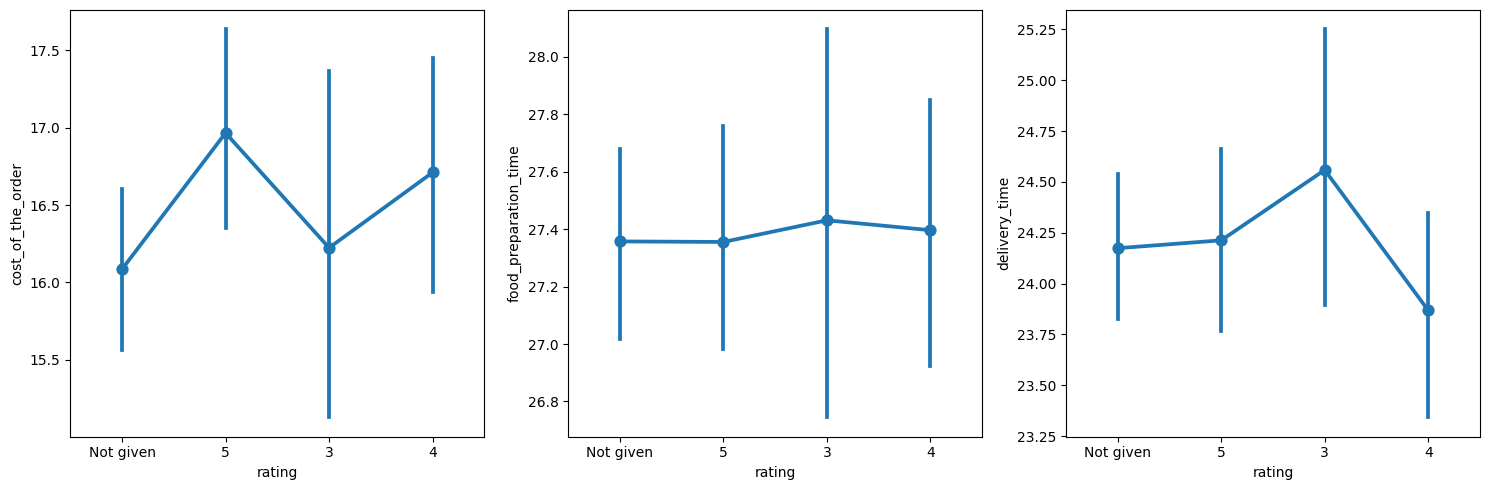

In [27]:
# Create a variable with only numerical columns
numeric_columns = foodhub_df.select_dtypes(include = 'number').columns

# Drop order_id, customer_id columns from numeric_columns variable as they are not necessary for visualization
numeric_columns = numeric_columns.drop(['order_id', 'customer_id'])

# Create point plots, where x-axis represents rating and y-axis represent numeric columns using for loop
plt.figure(figsize = (15, 5))

for i, col in enumerate(numeric_columns):
  plt.subplot(1, 3, i+1) # Create a subplot in a grid of 1 row and 3 columns
  sns.pointplot(data = foodhub_df, x = 'rating', y = col)
  plt.tight_layout()

plt.show()

**Observations:**

1. Rating vs cost of the order

* Orders with a 5-star rating have the highest average cost.
* Orders with a 3-star rating have slightly lower average cost.
* Orders with 4-star ratings are also relatively high in cost.
* Orders with no rating given have moderate average cost.
* This suggests that customers may give higher ratings to slightly higher-value orders.

2. Rating vs food preparation time

* The average food preparation time is very similar across all ratings.
* There is no major difference in preparation time between 3, 4, and 5-star ratings.
* This suggests preparation time may not strongly affect customer ratings.

3. Rating vs delivery time

* Orders with a 3-star rating have slightly higher average delivery time.
* Orders with a 4-star rating have slightly lower average delivery time.
* The differences are small, but faster deliveries may slightly improve ratings.
* Delivery time does not vary drastically across rating categories.

##### Correlation Matrix of Numerical Variables

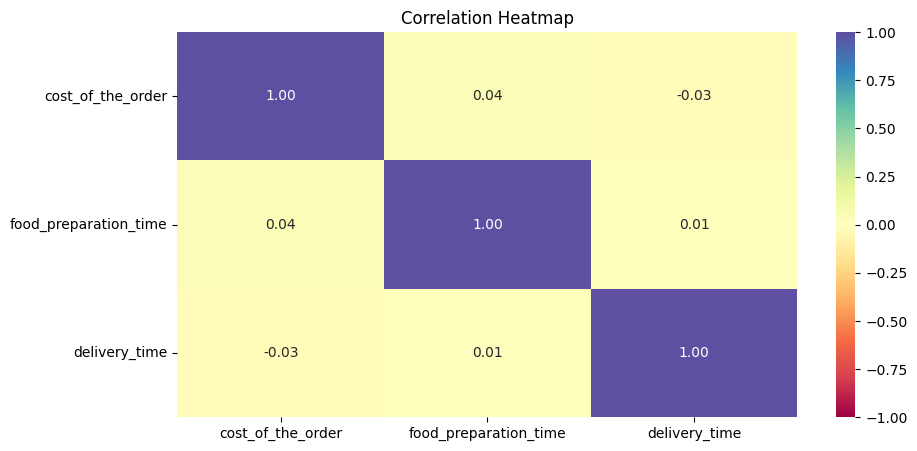

In [28]:
# Create a variable with only numerical columns
numeric_columns = foodhub_df.select_dtypes(include = 'number').columns

# Drop order_id, customer_id columns from numeric_columns variable as they are not necessary for visualization
numeric_columns = numeric_columns.drop(['order_id', 'customer_id'])

# Create a correlation matrix of numeric columns
plt.figure(figsize = (10, 5))
sns.heatmap(data = foodhub_df[numeric_columns].corr(), annot = True, cmap = 'Spectral', fmt = '.2f', vmin = -1, vmax =1)
plt.title('Correlation Heatmap')
plt.show()

**Observations:**

* The correlation between cost of the order and food preparation time is 0.04, which is very close to 0. This means there is almost no relationship between order cost and preparation time.
* The correlation between cost of the order and delivery time is -0.03, which is also very close to 0. This means order cost does not affect delivery time.
* The correlation between food preparation time and delivery time is 0.01, again very close to 0. This shows there is no strong relationship between preparation time and delivery time.

##### Total Revenue generated by each restaurant

In [29]:
# Group the dataset by restaurant_name and calculate the sum of cost_of_the_order
# Sort the values in the descending order by setting ascending to False
foodhub_df.groupby('restaurant_name')['cost_of_the_order'].sum().sort_values(ascending = False).head(10)

,cost_of_the_order
restaurant_name,
Shake Shack,3579.53
The Meatball Shop,2145.21
Blue Ribbon Sushi,1903.95
Blue Ribbon Fried Chicken,1662.29
Parm,1112.76
RedFarm Broadway,965.13
RedFarm Hudson,921.21
TAO,834.50
Han Dynasty,755.29


**Observations:**

* Shake shack generates the highest revenue (3579.53), clearly leading among all restaurants.
* The meatball shop is the second highest revenue generator (2145.21).
* Blue ribbon sushi and blue ribbon fried chicken also contribute strong revenue.
* There is a noticeable drop in revenue after the top five restaurants.
* Restaurants like Redfarm broadway, Redfarm hudson, Tao, Han dynasty, and Blue ribbon sushi bar & grill generate comparatively lower revenue.
* The top few restaurants contribute a large share of total revenue, showing revenue concentration among popular restaurants.
* Shake shack stands out as the most valuable restaurant in terms of both order volume and revenue.

#### Identification of restaurants eligible for promotional offer based on rating criteria (order count > 50 & average rating > 4)

In [30]:
# Create a copy of the dataset excluding rows where the rating is Not given
df_rated = foodhub_df[foodhub_df['rating'] != 'Not given'].copy()

# Convert the rating column from string to integer type for proper numerical analysis
df_rated['rating'] = df_rated['rating'].astype('int')

# Group the filtered data by restaurant_name and count the number of ratings for each restaurant
# Sort the count in descending order and and reset the index to convert the result into a clean DataFrame
df_rated_count = df_rated.groupby('restaurant_name')['rating'].count().sort_values(ascending = False).reset_index()
df_rated_count.head()

,restaurant_name,rating
0,Shake Shack,133
1,The Meatball Shop,84
2,Blue Ribbon Sushi,73
3,Blue Ribbon Fried Chicken,64
4,RedFarm Broadway,41


In [31]:
# Filter restaurants that have more than 50 ratings
restaurant_names = df_rated_count[df_rated_count['rating'] > 50]['restaurant_name']

# Create a subset of df_rated containing only these restaurants
df_rating_count_greater_than_50 = df_rated[df_rated['restaurant_name'].isin(restaurant_names)].copy()

# Calculate the average rating for each of these restaurants by grouping them with restaurant_name
# sort the results in descending order, reset the index, and drop other columns
df_rating_count_greater_than_50_average = df_rating_count_greater_than_50.groupby('restaurant_name')['rating'].mean().sort_values(ascending = False).reset_index().dropna()

# Further filter restaurants to include only those with an average rating greater than 4
# Sort them by rating in descending order by resetting the index
df_rating_count_greater_than_50_and_average_rating_greater_than_4 = df_rating_count_greater_than_50_average[df_rating_count_greater_than_50_average['rating'] > 4].sort_values(by = 'rating', ascending = False).reset_index(drop = True)
df_rating_count_greater_than_50_and_average_rating_greater_than_4

,restaurant_name,rating
0,The Meatball Shop,4.511905
1,Blue Ribbon Fried Chicken,4.328125
2,Shake Shack,4.278195
3,Blue Ribbon Sushi,4.219178


**Observations:**

* The following restaurants meet the criteria of having more than 50 ratings and an average rating greater than 4:

  1. The meatball shop – average rating: 4.51
  2. Blue ribbon fried chicken – average rating: 4.33
  3. Shake shack – average rating: 4.28
  4. Blue ribbon sushi – average rating: 4.22
* The meatball shop has the highest average rating among the eligible restaurants.
* All the above four restaurants have strong customer satisfaction (ratings above 4).
* These restaurants are strong candidates for promotional offers since they are both popular and highly rated.
* Promoting these restaurants can help attract more customers and increase overall sales.

#### Calculation of net revenue generated by the company based on 25 percent commission on orders above 20 dollars and 15 percent commission on orders above 5 dollars

In [32]:
# Define a function to calculate revenue based on the cost of the order
def calculate_revenue(x):
  if x > 20:
    return x * 0.25
  elif x > 5:
    return x * 0.15
  else:
    return x * 0.0

# Apply the calculate_revenue function to the 'cost_of_the_order' column and create a new column 'revenue' in the DataFrame
foodhub_df['revenue'] = foodhub_df['cost_of_the_order'].apply(calculate_revenue)
foodhub_df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time,revenue
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20,7.6875
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23,1.8120
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28,1.8345
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15,7.3000
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24,1.7385


In [33]:
# Calculate the total revenue generated from all orders by summing up the values in the revenue column
Total_Revenue = foodhub_df['revenue'].sum()
Total_Revenue

np.float64(6166.303)

**Observations:**

* **The net revenue generated by the company across all orders is 6166.30 dollars.**
* This revenue is earned through:
  + 25% commission on orders costing more than 20 dollars
  + 15% commission on orders costing more than 5 dollars
* The commission-based model generates a substantial amount of revenue.
* Higher-value orders (above 20 dollars) likely contribute a significant portion of the total revenue due to the higher commission rate.
* The pricing and commission structure appears effective in generating consistent company earnings.

#### Percentage of food orders taking more than 60 minutes from order placement including preparation and delivery time

In [34]:
# Create a new column 'total_time' that represents the sum of food_preparation_time and delivery_time for each order
foodhub_df['total_time'] = foodhub_df['food_preparation_time'] + foodhub_df['delivery_time']

# Calculate the total number of orders where the total time exceeds 60 minutes
# Divide by the total number of orders and multiply by 100 to get a percentage
(foodhub_df[foodhub_df['total_time'] > 60]['order_id'].count() / foodhub_df.shape[0]) * 100

np.float64(10.537407797681771)

**Observations:**

* **Approximately 10.54% of the orders take more than 60 minutes from order placement to final delivery (including preparation and delivery time).**
* This implies that about 1 in every 10 orders takes longer than one hour.
* The majority of orders (around 89%) are delivered within 60 minutes.
* While overall delivery performance seems good, the company may want to investigate the causes of delays for the 10% of slower orders to improve customer satisfaction.

#### Analysis of variation in mean delivery time of orders between weekdays and weekends

In [35]:
# Group the data by day_of_the_week and calculate the average (mean)
foodhub_df.groupby('day_of_the_week')['delivery_time'].mean()

,delivery_time
day_of_the_week,
Weekday,28.340037
Weekend,22.470022


**Observations:**

* **The mean delivery time on weekdays is 28.34 minutes.**
* **The mean delivery time on weekends is 22.47 minutes.**
* Delivery time is approximately 6 minutes longer on weekdays compared to weekends.
* Orders are delivered faster on weekends than on weekdays.
* This may suggest heavier traffic, operational delays, or staffing differences during weekdays.
* The company may need to improve weekday delivery efficiency to match weekend performance.

#### Conclusions and business recommendations based on analysis

**Conclusions:**

* The analysis shows that a small number of popular restaurants generate a large share of total orders and revenue. Restaurants such as shake shack, the meatball shop, and blue ribbon sushi consistently perform well in both order volume and earnings. This indicates that customer demand is concentrated among a few strong brands.
* American cuisine is the most popular, especially on weekends, followed by japanese and italian cuisines. Weekend demand is significantly higher than weekday demand, suggesting that customers are more likely to order food during their free time. This pattern highlights the importance of weekend-focused strategies.
* Customer satisfaction appears to be strong, as most ratings are 4 and 5 stars. However, a large number of customers do not leave ratings, which limits the amount of feedback available for performance improvement. Encouraging more customers to provide ratings could offer deeper insights.
* Delivery performance is generally efficient, with an average delivery time of around 24 minutes. However, about 10 percent of orders take more than 60 minutes from placement to delivery. Additionally, delivery times are noticeably longer on weekdays compared to weekends, indicating possible operational inefficiencies during weekdays.
* The correlation analysis shows that order cost, preparation time, and delivery time are not strongly related. This suggests that higher-priced orders do not necessarily take longer to prepare or deliver, indicating stable operational processes. The commission-based revenue model is effective, generating strong overall revenue, especially from higher-value orders.

**Recommendations:**

* The company should focus on promoting high-performing and highly rated restaurants, as they already attract strong demand and generate high revenue. Highlighting these restaurants in advertisements and offering targeted promotions can further increase sales.
* Since weekday delivery times are longer, the company should improve weekday operations by optimizing staffing levels, delivery routes, and coordination between restaurants and delivery personnel. Reducing delays will improve customer satisfaction.
* The company should investigate the reasons behind orders that take more than 60 minutes. Identifying issues such as traffic, preparation delays, or staffing shortages can help reduce long delivery times and enhance the customer experience.
* Encouraging customers to leave ratings through small incentives such as discount coupons or loyalty points can improve feedback collection. More feedback will help the company better understand customer preferences and service quality.
* The company should strengthen partnerships with restaurants offering popular cuisines such as american and japanese, as these generate high demand. At the same time, it can support lower-performing restaurants through targeted promotions to balance demand across the platform.
* Finally, rewarding loyal customers with discount vouchers or loyalty programs can help improve customer retention and encourage repeat orders, which will support long-term business growth.

---

In [37]:
!jupyter nbconvert --to html '/content/drive/MyDrive/Projects/FoodHub Analytics_Restaurant Demand & Delivery Insights/FoodHub Analytics_Restaurant Demand & Delivery Insights.ipynb'

[NbConvertApp] Converting notebook /content/drive/MyDrive/Projects/FoodHub Analytics_Restaurant Demand & Delivery Insights/FoodHub Analytics_Restaurant Demand & Delivery Insights.ipynb to html
[NbConvertApp] Writing 385257 bytes to /content/drive/MyDrive/Projects/FoodHub Analytics_Restaurant Demand & Delivery Insights/FoodHub Analytics_Restaurant Demand & Delivery Insights.html
